In [31]:
# importing libraries

import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

### For Measurement purpose
This measure() function skips the necessity of downloading third party programs to get the radius of circles. So you won't need fiji anymore(!) :)

In [32]:
## Just a Function to Measure something from an image, 
## to get actual length set opt=1
## to get pixel length set opt=2

class measure:
    def __init__(self):
        self.drawing = False            # true if mouse pressed
        self.ix, self.iy = -1,-1        
        self.i = 0
        self.num_pixels = 0
        self.actual_len = 0
        self.line_color = (0,255,0)
        self.text_color = (255,0,0)
        self.line_thickness = 2
        self.text_thickness = 1
        self.font = cv2.FONT_HERSHEY_SIMPLEX
        self.font_size = 0.5
        self.img1 = []
        # self.tar_dir = dir              # Target Directory
        # self.ini = init                 # Initial Picture Number

    # mouse callback function
    def draw(self, event, x, y, flags, param):
        img = param
        if event == cv2.EVENT_LBUTTONDOWN:      # On pressing Left button of mouse
            self.drawing = True
            self.ix, self.iy = x, y

        elif event == cv2.EVENT_MOUSEMOVE:      # On moving the mouse or cursor
            # try:
            if self.drawing == True:
                self.img1 = img.copy()                           # Every time mouse moves the lines are drawn into a fresh copy of the original image
                cv2.line(self.img1,(self.ix, self.iy),(x,y), self.line_color, self.line_thickness)    # Draws line as mouse moves
                self.num_pixels = max(abs(self.ix-x), abs(self.iy-y))                            # Calculates number of pixels
                cv2.putText(self.img1, "Number of pixels: "+str(self.num_pixels), 
                        (10,20), self.font, self.font_size, self.text_color, self.text_thickness)
                self.actual_len = ((self.ix-x)**2 + (self.iy-y)**2)**0.5                         # Calculates original distance between the points
                cv2.putText(self.img1, "Actual Length: "+str(self.actual_len), 
                        (10,40), self.font, self.font_size, self.text_color, self.text_thickness)
                cv2.imshow('image', self.img1)

            ### WEll THE ISSUE IS SOLVED! ###
            ### implemented class instead of nested functions ###
            # except Exception:
            #     if i==0: print("Well, the 'NameError: name 'drawing' is not defined' happened again. \
            #                     If you can solve the issue it would be nice of you :) ")
            #     i+=1

        elif event == cv2.EVENT_LBUTTONUP:
            self.drawing = False
            cv2.putText(self.img1, "Press \"SPACE\" to go the next phase", 
                            (10,60), self.font, self.font_size, self.text_color, self.text_thickness)
            cv2.imshow('image',self.img1)


    def main(self, text, img, opt=1):
        # Getting text height and width
        (txtWidth, txtHeight) = cv2.getTextSize(text, self.font, self.font_size, self.text_thickness)[0]
        txtHeight += 10

        # Creating mask as the width of the text could exceed the original image
        mask = np.zeros((txtHeight, txtWidth, 3), dtype=np.uint8)   # create a blank image
        mask.fill(255)                                              # fill the image with white
        mask = cv2.putText(mask, text, (0,15), self.font, self.font_size, self.text_color, self.text_thickness, cv2.LINE_AA)
        mask = cv2.resize(mask, (img.shape[1], txtHeight))         # Resizing the masked text image to the original image
        # Merging process
        img[-txtHeight:, :, :] = cv2.bitwise_and(img[-txtHeight:, :, :], mask)

        cv2.namedWindow('image')
        cv2.imshow('image', img)

        while(1):
            cv2.setMouseCallback('image', self.draw, img)     # Draws line
            time.sleep(0.05)                            # Delays for 5 ms and make the lines appear when mouse moves
            k = cv2.waitKey(1) & 0xFF
            if k == 32:                                 # Pressing Space key closes the window and go to next phase
                break
        
        cv2.destroyAllWindows()
        
        if opt==2:
            return int(self.num_pixels)
        else:
            return int(self.actual_len)

### Initialization of variables
- You are free to change these
- However, you must change first 3 variables across different folders

In [33]:
# Initialization of variables

tar_dir = "N=2 data/20210202/2/Movie2120_"   # Target directory
N = 1072                          # Number of images to analyze, (Change this appropriately!)
init = 64                     # Start Number of the image folder

#micron_per_pixel is a microscope calibration parameter. This will be fixed for a given experiment. Do NOT change.
micron_per_pixel = 100/30.

tempP1 = 50                    # Temporary variable for parameter 1
tempP2 = 30                     # Temporary variable for parameter 2
pf = 0.1                        # Point factor for locating circle point
af = 0.4                          # Area factor -> differentiates two circles
red_color = (0,0,255)
green_color = (0,255,0)
blue_color = (255,0,0)
font = cv2.FONT_HERSHEY_SIMPLEX
font_size = 0.5
font_thick = 1
t = np.linspace(1, N, N)

### Core functionality starts from here

In [34]:
# Function to calculate polar coordinates: (x,y) -> r, theta

def xy2polar(x, y):
    r = (x**2 + y**2)**0.5
    theta = np.arctan2(y, x)/3.1416*180
    return r, theta

#### Creating Slider functionaility

In [35]:
class sliding:
    def __init__(self, tar_dir, rad, ini, P1, P2):
        self.tar_dir = tar_dir
        self.rad = rad
        self.ini = ini
        self.tempP1 = P1
        self.tempP2 = P2

    def sliding(self):
        img = cv2.imread(self.tar_dir+str(self.ini)+".tif", cv2.IMREAD_GRAYSCALE)
        img_blurred = cv2.blur(img, (3,3))
        cimg = cv2.cvtColor(img_blurred, cv2.COLOR_GRAY2BGR)
        
        # It does nothing but passes variable of createTrackbar functon
        def nothing(x):
            pass
        
        wndw = 'detected circles'                                   # Just a name of the window, you can change any name you want
        cv2.imshow(wndw, cimg)
        
        cv2.createTrackbar('param1', wndw, self.tempP1, 200, nothing)    #Creates slider for parameter 1
        cv2.createTrackbar('param2', wndw, self.tempP2, 100, nothing)    #Creates slider for parameter 2

        # Unending loop to help you slide through param1 and param2 variables
        # and visualize which are the best values to get optimum circles
        while(True):
            cv2.imshow(wndw, cimg)
            k = cv2.waitKey(1) & 0xFF
            if k == 32:                                             # Pressing 'Space' key closes the window and go to next phase
                break
            cimg = cv2.cvtColor(img_blurred, cv2.COLOR_GRAY2BGR)    # For every loop takes a fresh image
        
            p1 = cv2.getTrackbarPos('param1', wndw)                 # Gets the slider position of Parameter 1
            p2 = cv2.getTrackbarPos('param2', wndw)                 # Gets the slider position of Parameter 2
            
            # These functions create errors when sliders are moved out of their calculation range
            # So, I used try-catch method of handling errors
            try:        
                # HoughCircles function simply detect circles with given parameters
                # However tweaking these parameters are tricky that's why I employed
                # sliders that you can interact with to tweak with values and see
                # changes realtime
                circles = cv2.HoughCircles(img_blurred, cv2.HOUGH_GRADIENT, 1, 20, 
                                    param1=p1,param2=p2,minRadius=int(self.rad-self.rad*pf),maxRadius=int(self.rad+self.rad*pf))
                circles = np.uint16(np.around(circles))
                
                # num_cir = len(circles[0,:])
                # print(repr(circles))

                # x = np.array([])
                # y = np.array([])
                # rd = np.array([])

                if circles is not None:
                    count = 0
                    for j in circles[0,:]:
                        # print(j[0])
                        # print(j[1])
                        # print(j[2])
                        cv2.circle(cimg, (j[0], j[1]), j[2], green_color, 2)  # The outer green circle drawn
                        cv2.circle(cimg, (j[0], j[1]), 2, red_color, 3)     # The center as red circle
                        
                        # x = np.r_[x, j[0]]
                        # y = np.r_[y, j[1]]
                        # rd = np.r_[rd, j[2]]

                        cv2.putText(cimg, str(count+1)+":("+str(j[0])+", "+str(j[1])+")", # Every circle counted and added as text
                                    (j[0]+j[2], j[1]-j[2]), 
                                    font, font_size, red_color, font_thick)
                        
                        count+=1

            except Exception as e:
                # So, the logic works like this - 
                # if you did not slide through the param1 slider
                # then you changed the param2 slider only and vice versa
                if p1 == self.tempP1:                    
                    val = abs(self.tempP2 - p2)                          # how much you have slide through
                    cv2.setTrackbarPos('param2', wndw, p2 - val)    # if you exceeded the limit, it would set the slider to the last known working condition
                elif p2 == self.tempP2:  
                    val = abs(self.tempP1 - p1)                          # how much you have slide through
                    cv2.setTrackbarPos('param1', wndw, p1 - val)    # if you exceeded the limit, it would set the slider to the last known working condition
                print("You've reached the breaking point! \n")         # Just to let you know!
                print(e)                                               # Printing the error
                time.sleep(2)                                       # Making delay will let you know that error happened

            self.tempP1 = p1                                             # If everything works smoothly records for future comparison
            self.tempP2 = p2

            cv2.putText(cimg, "Press \"SPACE\" to go the next phase",   # Just to help you out
                        (10,20), font, font_size, blue_color, font_thick)
            
        cv2.destroyAllWindows()
        return (circles)
                

### Measurement
All the functions declared above, run here from now on

In [36]:
# Measurement

sample_img = cv2.imread(tar_dir + str(init) + ".tif")    # Sample image to read from target directory and initial image number
m = measure()   # Creating object from class
rad = int(m.main("Draw a line across the diameter of any circle", sample_img)/2)

# Visual Slider control works here
s = sliding(tar_dir, rad, init, tempP1, tempP2)     # just object creation
prev_circles = s.sliding()

# We take the param1 & param2 values for across all images
p1 = s.tempP1
p2 = s.tempP2


In [37]:
# print(repr(rd))
# print(prev_circles[0,:])
# circle = np.zeros([len(prev_circles[0,:]), 3, N])
# print(repr(circle))

In [38]:

# Circle variable declaration
circle_xy = np.zeros([len(prev_circles[0,:]), 3, N], dtype=int)

for i in range(N):
    curr_dir = tar_dir+str(init + i)+".tif"
    img = cv2.imread(curr_dir, cv2.IMREAD_GRAYSCALE) # Every time the function loops it increases the file number, thus going to next frame
    img_blurred = cv2.blur(img, (3,3))
    cimg = cv2.cvtColor(img_blurred, cv2.COLOR_GRAY2BGR)
 
    circles = cv2.HoughCircles(img_blurred, cv2.HOUGH_GRADIENT, 1, 20, 
                                    param1=p1, param2=p2, minRadius=int(rad-rad*pf), maxRadius=int(rad+rad*pf))
    circles = np.uint16(np.around(circles))
    
    # print(str(i+init)+": "+str(len(circles[0,:])))     # for diagnosis of later circle numbers

    # Problem: Sometimes Houghcircle algorithm can detect multiple circles depending on 
    # internal parameter param1 and param2.
    # Solution: So, this portion checks the number of circles previously instructed 
    # by user and the currently detected circles. If it does not match
    # then sliding mechanism is called again to get desired number of circles.
    OKAY = False
    while OKAY == False:
        if len(circles[0,:]) == len(prev_circles[0,:]):
            OKAY = True
        else:
            print(len(circles[0,:]))
            s = sliding(tar_dir, rad, (init+i), p1, p2)
            prev_circles = s.sliding()
            # We take the param1 & param2 values for across all images (Again)
            p1 = s.tempP1
            p2 = s.tempP2
            circles = cv2.HoughCircles(img_blurred, cv2.HOUGH_GRADIENT, 1, 20, 
                                    param1=p1, param2=p2, minRadius=int(rad-rad*pf), maxRadius=int(rad+rad*pf))
            circles = np.uint16(np.around(circles))
            OKAY = False
    
    # Problem: Sometimes Houghcircle algorithm can detect Circle-1 as Circle-2
    # or vice-versa in the next image.
    # Solution: Comparing previous co-ordinates with the present circle co-ordinates
    # If they are close within certain boundary then we can say that they are same
    # circle just got shifted.
    forward = False
    c_count = 0       # Present circle count
    for c in circles[0,:]:
        a, b, r = c[0], c[1], c[2]

        prev_c_count = 0    # Previous circle count
        for p in prev_circles[0,:]:
            prev_a, prev_b, prev_r = p[0], p[1], p[2]

            # Area is defined with area factor multiplied
            prev_a_high = prev_a + prev_a * af
            prev_a_low = prev_a - prev_a * af
            prev_b_high = prev_b + prev_b * af
            prev_b_low = prev_b - prev_b * af
            # prev_a_high = prev_a + rad
            # prev_a_low = prev_a - rad
            # prev_b_high = prev_b + rad
            # prev_b_low = prev_b - rad

            if (a > prev_a_low and a < prev_a_high) and (b > prev_b_low and b < prev_b_high):
               
                circle_xy[prev_c_count][0][i] = a*micron_per_pixel
                circle_xy[prev_c_count][1][i] = b*micron_per_pixel
                circle_xy[prev_c_count][2][i] = r

                # print("Image No: "+ str(i))
                # print(circle_xy)
                # print("-------------------------")

                if c_count == prev_c_count:
                    forward = True
                else:
                    forward = False
                
            
            prev_c_count += 1
        
        c_count += 1
    
    # It corrects the order of N number of circles
    if forward:
        prev_circles[0,:] = circles[0,:]            
    else:
        prev_circles[0,:] = circles[0,:][::-1]

In [39]:
r = np.empty([len(prev_circles[0,:]), N])
theta = np.empty([len(prev_circles[0,:]), N])

#Find the center of the large circle in the image 
center1_x = 208*micron_per_pixel; center1_y = 218*micron_per_pixel

# It basically takes every (x, y) -> converts into (r, theta)
for i in range(len(prev_circles[0,:])):         # Loops for number of circles previously defined
        for k in range(N):                      # Number of images scanned = that number of data points
            x = circle_xy[i][0][k]
            y = circle_xy[i][1][k]
            rd = circle_xy[i][2][k]

            r[i][k], theta[i][k] = xy2polar(x-center1_x, center1_y-y)


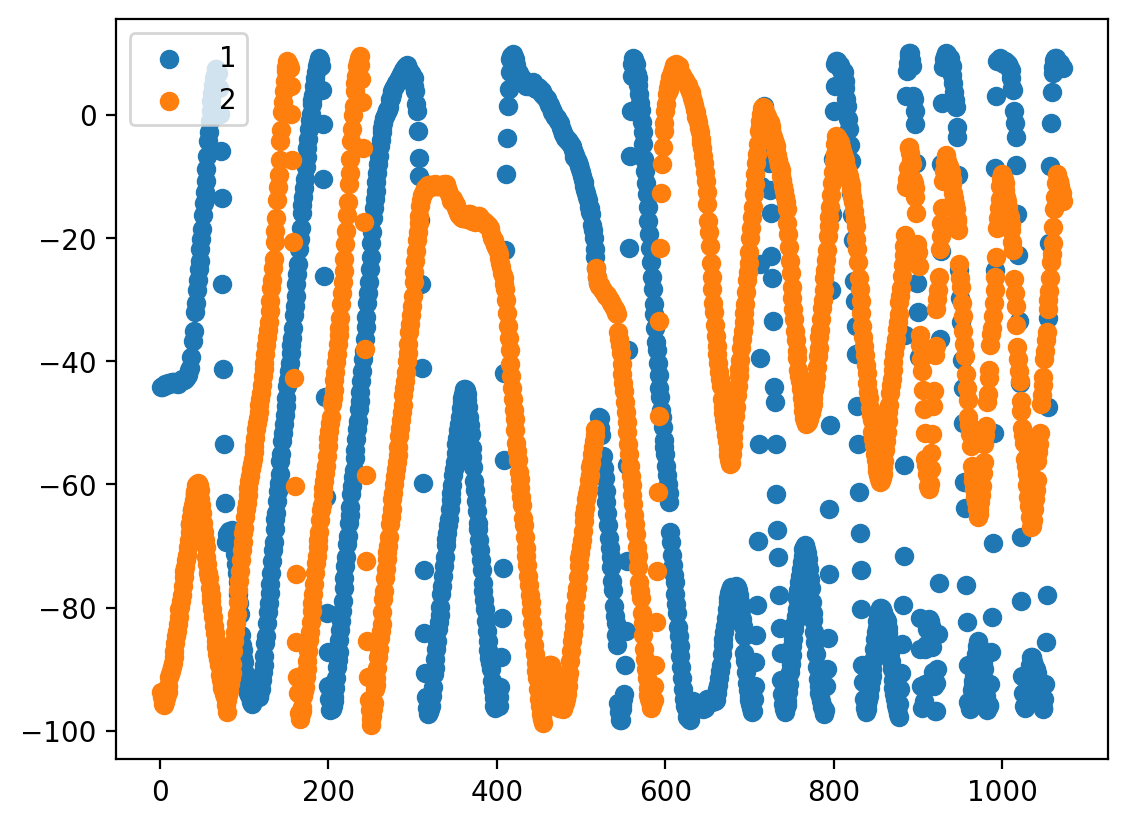

In [40]:
plt.figure(dpi=200)

plt.scatter(t, theta[0])    # For first circle
plt.scatter(t, theta[1])    # for 2nd circle

# plt.xlim(0,20)
plt.legend(['1','2'])